<a href="https://colab.research.google.com/github/storylord/topic_modelling/blob/main/nlp_topic_modelling_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic modelling

In statistics and natural language processing, a topic model is a type of statistical model for discovering the abstract "topics" that occur in a collection of documents. (Wikipedia)
It is based on the assumption that:
- A text (document) is composed of several topics
- A topic is composed of a collection of words

## 1. Data load

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "spsayakpaul/arxiv-paper-abstracts",
  "arxiv_data.csv",)

df.head()

100%|██████████| 21.4M/21.4M [00:00<00:00, 64.7MB/s]

Extracting zip of arxiv_data.csv...


,titles,summaries,terms
0,Survey on Semantic Stereo Matching / Semantic ...,Stereo matching is one of the widely used tech...,"['cs.CV', 'cs.LG']"
1,FUTURE-AI: Guiding Principles and Consensus Re...,The recent advancements in artificial intellig...,"['cs.CV', 'cs.AI', 'cs.LG']"
2,Enforcing Mutual Consistency of Hard Regions f...,"In this paper, we proposed a novel mutual cons...","['cs.CV', 'cs.AI']"
3,Parameter Decoupling Strategy for Semi-supervi...,Consistency training has proven to be an advan...,['cs.CV']
4,Background-Foreground Segmentation for Interio...,"To ensure safety in automated driving, the cor...","['cs.CV', 'cs.LG']"


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from kagglehub import KaggleDatasetAdapter

# data size
data_size = 1000
# Load the DataFrame and truncate to the first 10,000 rows
df = df.head(data_size)
df = df['summaries']
print(f"Dataset truncated to {len(df)} rows.")

Dataset truncated to 1000 rows.


## 2. Data cleaning and Preprocessing

In [ ]:
import re
def clean_str(string):
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r'\s+', ' ', string)
    # Remove backslashes and parentheses first
    string = re.sub(r"[\\()]+", " ", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip().lower()
df_clean = df.apply(clean_str)
df_clean.head()

,summaries
0,stereo matching is one of the widely used tech...
1,the recent advancements in artificial intellig...
2,"in this paper , we proposed a novel mutual con..."
3,consistency training has proven to be an advan...
4,"to ensure safety in automated driving , the co..."


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
tokenized_df_clean = [word_tokenize(word) for word in df_clean]
len(tokenized_df_clean)

1000

In [ ]:
print(tokenized_df_clean[:1])

[['stereo', 'matching', 'is', 'one', 'of', 'the', 'widely', 'used', 'techniques', 'for', 'inferring', 'depth', 'from', 'stereo', 'images', 'owing', 'to', 'its', 'robustness', 'and', 'speed', 'it', 'has', 'become', 'one', 'of', 'the', 'major', 'topics', 'of', 'research', 'since', 'it', 'finds', 'its', 'applications', 'in', 'autonomous', 'driving', ',', 'robotic', 'navigation', ',', '3d', 'reconstruction', ',', 'and', 'many', 'other', 'fields', 'finding', 'pixel', 'correspondences', 'in', 'non', 'textured', ',', 'occluded', 'and', 'reflective', 'areas', 'is', 'the', 'major', 'challenge', 'in', 'stereo', 'matching', 'recent', 'developments', 'have', 'shown', 'that', 'semantic', 'cues', 'from', 'image', 'segmentation', 'can', 'be', 'used', 'to', 'improve', 'the', 'results', 'of', 'stereo', 'matching', 'many', 'deep', 'neural', 'network', 'architectures', 'have', 'been', 'proposed', 'to', 'leverage', 'the', 'advantages', 'of', 'semantic', 'segmentation', 'in', 'stereo', 'matching', 'this', 

# 2.1 Word cloud

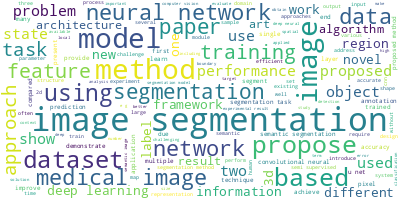

In [ ]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the tokens in each list into strings, then join those strings into one large string
full_text = ' '.join([' '.join(doc) for doc in tokenized_df_clean])
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')
# Generate a word cloud using the combined string
wordcloud.generate(full_text)
# Visualize the word cloud
wordcloud.to_image()

# 3. Building the sparse matrix and ftting LDA model

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
# Initialize spacy model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Lemmatization using nlp.pipe for efficiency with the original cleaned strings
lem_data = []
for doc in nlp.pipe(df_clean, batch_size=1000):
    # Keep only Noun, Adj, Verb, Adverb if needed, otherwise just grab lemma_
    lem_data.append([token.lemma_ for token in doc if token.pos_ in ["NOUN", "ADJ", "VERB", "ADV"]])

print(lem_data[:1])

[['matching', 'widely', 'use', 'technique', 'infer', 'depth', 'stereo', 'image', 'owe', 'robustness', 'speed', 'become', 'major', 'topic', 'research', 'find', 'application', 'autonomous', 'driving', 'robotic', 'navigation', '3d', 'reconstruction', 'many', 'other', 'field', 'find', 'pixel', 'correspondence', 'non', 'texture', 'occluded', 'reflective', 'area', 'major', 'challenge', 'stereo', 'matching', 'recent', 'development', 'show', 'semantic', 'cue', 'image', 'segmentation', 'use', 'improve', 'result', 'stereo', 'matching', 'many', 'deep', 'neural', 'network', 'architecture', 'propose', 'leverage', 'advantage', 'semantic', 'segmentation', 'stereo', 'matching', 'paper', 'aim', 'give', 'comparison', 'state', 'art', 'network', 'term', 'accuracy', 'term', 'speed', 'high', 'importance', 'real', 'time', 'application']]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vectorizer = CountVectorizer(
    min_df=5,        # ignore terms appearing in fewer than 5 docs
    max_df=0.90,     # ignore terms appearing in more than 90% of docs
    max_features=20000,  # cap vocabulary size for memory/speed
    ngram_range=(1, 2)   # include bigrams like "neural network"
)
# Join the lemmatized tokens back into strings for the vectorizer
lem_strings = [' '.join(doc) for doc in lem_data]
X = vectorizer.fit_transform(lem_strings)

In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 98380 stored elements and shape (1000, 4113)>

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=5, random_state = 0, learning_method='online', n_jobs=-1, doc_topic_prior = 0.06, topic_word_prior = 0.01, learning_decay=0.711 )
lda.fit(X)

LatentDirichletAllocation(doc_topic_prior=0.06, learning_decay=0.711,
                          learning_method='online', n_components=5, n_jobs=-1,
                          random_state=0, topic_word_prior=0.01)

In [ ]:
# Diagnostic
print("Log Likelihood Score: ",lda.score(X))
print("Model Perplexity: ", lda.perplexity(X))

Log Likelihood Score:  -960828.7885529045
Model Perplexity:  1817.9742109864783


In [ ]:
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-10 - 1:-1]])



Topic 0:
['feature', 'transformer', 'attention', 'scale', 'context', 'image segmentation', 'module', 'medical', 'medical image', 'multi']
Topic 1:
['contextual', 'representation', 'modal', 'contextual information', 'information', 'level', 'stereo', 'normalization', 'batch', 'patch']
Topic 2:
['use', 'method', 'propose', 'model', 'image segmentation', 'base', 'network', 'approach', 'deep', 'result']
Topic 3:
['network', 'propose', 'method', 'dataset', 'image segmentation', 'semantic', 'task', 'model', 'feature', 'object']
Topic 4:
['domain', 'datum', 'target', 'adaptation', 'modality', 'source', 'method', 'label', 'cardiac', 'prior']


# Visualisation

In [ ]:
# Install if needed
!pip install pyLDAvis==3.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.1 MB/s eta 0:00:00


In [ ]:


import pyLDAvis
import pyLDAvis.lda_model  # sklearn integration

pyLDAvis.enable_notebook()
# Prepare the visualisation — this maps sklearn's LDA + CountVectorizer into pyLDAvis format
vis_data = pyLDAvis.lda_model.prepare(
    lda,          # your fitted LDA model
    X,            # your document-term matrix
    vectorizer,   # your fitted CountVectorizer
    mds='tsne',   # dimensionality reduction: 'tsne' or 'pcoa' (faster)
    sort_topics=False  # keep topic numbering consistent with your printed topics above
)

pyLDAvis.display(vis_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Optimisation

Optimise parameters with random search

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from scipy.stats import randint

# Define Search Param - can now use distributions instead of discrete lists
search_params = {
    'n_components': randint(2, 21),
    'learning_decay': uniform(loc=0.5, scale=0.4),  # samples uniformly between 0.5 and 0.9
    'doc_topic_prior': uniform(loc=0.01, scale=0.09),  # alpha, between 0.01 and 0.1
    'topic_word_prior': uniform(loc=0.01, scale=0.09)  # beta, between 0.01 and 0.1
}

# Init the Model
lda = LatentDirichletAllocation(
    max_iter=5,
    learning_method='online',
    learning_offset=50.,
    random_state=0
)

# Init Random Search — n_iter controls how many combinations are sampled
model = RandomizedSearchCV(
    lda,
    param_distributions=search_params,
    n_iter=50,          # number of random combinations to try
    cv=3,               # cross-validation folds
    scoring='perplexity' if False else None,  # LDA uses log-likelihood by default
    random_state=42,
    verbose=2
)

# Run the search
model.fit(X)

# Best Model
best_lda_model = model.best_estimator_
print("Best Model's Params: ", model.best_params_)
print("Best Log Likelihood Score: ", model.best_score_)
print("Model Perplexity: ", best_lda_model.perplexity(X))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END doc_topic_prior=0.043708610696262626, learning_decay=0.8802857225639664, n_components=12, topic_word_prior=0.08017219002454923; total time=   4.2s
[CV] END doc_topic_prior=0.043708610696262626, learning_decay=0.8802857225639664, n_components=12, topic_word_prior=0.08017219002454923; total time=   6.5s
[CV] END doc_topic_prior=0.043708610696262626, learning_decay=0.8802857225639664, n_components=12, topic_word_prior=0.08017219002454923; total time=   3.7s
[CV] END doc_topic_prior=0.06371651421518383, learning_decay=0.6783331011414364, n_components=12, topic_word_prior=0.05133240027692804; total time=   4.0s
[CV] END doc_topic_prior=0.06371651421518383, learning_decay=0.6783331011414364, n_components=12, topic_word_prior=0.05133240027692804; total time=   3.2s
[CV] END doc_topic_prior=0.06371651421518383, learning_decay=0.6783331011414364, n_components=12, topic_word_prior=0.05133240027692804; total time=   4.8s
[CV] 

Checking topic coherence

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
# Build gensim dictionary and corpus from your lemmatized data
dictionary = Dictionary(lem_data)
dictionary.filter_extremes(no_below=5, no_above=0.9)
corpus = [dictionary.doc2bow(doc) for doc in lem_data]

def compute_coherence(lda_model, vectorizer, lem_data, dictionary, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    topics = [
        [feature_names[i] for i in topic.argsort()[:-top_n - 1:-1]]
        for topic in lda_model.components_
    ]
    cm = CoherenceModel(topics=topics, texts=lem_data, dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

score = compute_coherence(best_lda_model, vectorizer, lem_data, dictionary)
print(f"Coherence Score: {score:.4f}")  # higher is better, typically 0.4–0.7 is good

Coherence Score: 0.4676


Fitting LDA with 2 topics...
  Coherence: 0.3839 | Perplexity: 1556.06
Fitting LDA with 3 topics...
  Coherence: 0.4515 | Perplexity: 1627.67
Fitting LDA with 4 topics...
  Coherence: 0.4895 | Perplexity: 1634.20
Fitting LDA with 5 topics...
  Coherence: 0.5407 | Perplexity: 1647.24
Fitting LDA with 6 topics...
  Coherence: 0.4894 | Perplexity: 1673.63
Fitting LDA with 7 topics...
  Coherence: 0.4531 | Perplexity: 1693.87
Fitting LDA with 8 topics...
  Coherence: 0.4508 | Perplexity: 1733.09
Fitting LDA with 9 topics...
  Coherence: 0.3822 | Perplexity: 1757.10
Fitting LDA with 10 topics...
  Coherence: 0.4486 | Perplexity: 1783.76
Fitting LDA with 11 topics...
  Coherence: 0.4192 | Perplexity: 1815.19
Fitting LDA with 12 topics...
  Coherence: 0.4052 | Perplexity: 1898.25
Fitting LDA with 13 topics...
  Coherence: 0.4304 | Perplexity: 1883.36
Fitting LDA with 14 topics...
  Coherence: 0.4471 | Perplexity: 1953.79
Fitting LDA with 15 topics...
  Coherence: 0.4022 | Perplexity: 1973.72


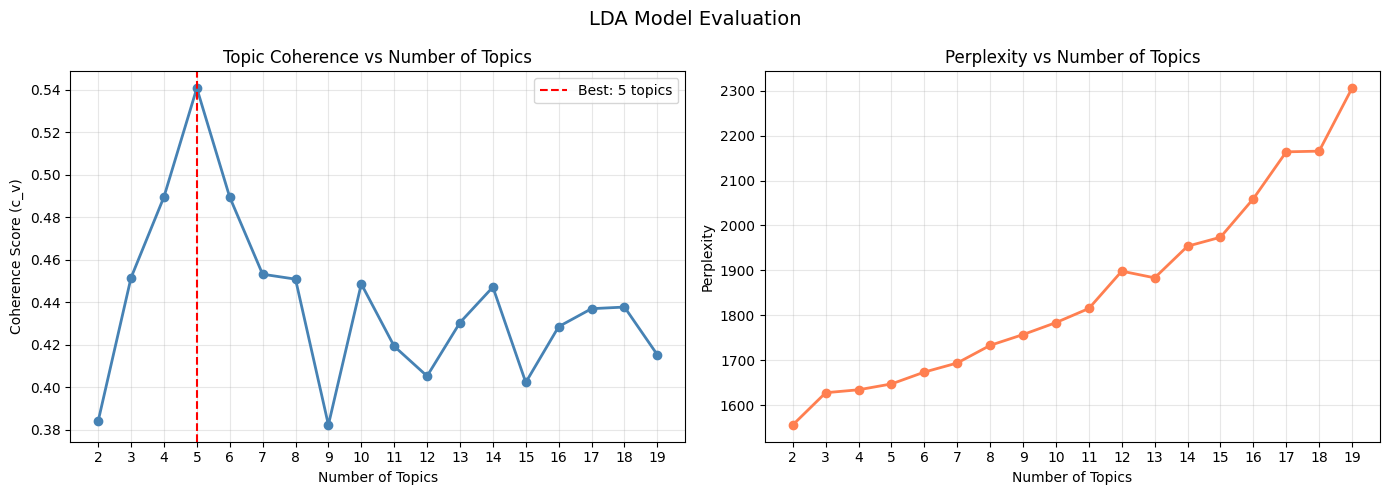


Best number of topics by coherence: 5 (score: 0.5407)


In [ ]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation

# Range of topic numbers to evaluate
topic_range = range(2, 20, 1)  # [2:20]
coherence_scores = []
perplexity_scores = []

for n in topic_range:
    print(f"Fitting LDA with {n} topics...")

    lda_model = LatentDirichletAllocation(
        n_components=n,
        max_iter=5,
        learning_method='online',
        learning_offset=50.,
        random_state=0
    )
    lda_model.fit(X)

    # Coherence
    score = compute_coherence(lda_model, vectorizer, lem_data, dictionary)
    coherence_scores.append(score)

    # Perplexity
    perplexity_scores.append(lda_model.perplexity(X))

    print(f"  Coherence: {score:.4f} | Perplexity: {lda_model.perplexity(X):.2f}")

# Plot both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence plot
ax1.plot(topic_range, coherence_scores, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score (c_v)')
ax1.set_title('Topic Coherence vs Number of Topics')
ax1.set_xticks(list(topic_range))
# Highlight the best score
best_n = list(topic_range)[coherence_scores.index(max(coherence_scores))]
ax1.axvline(x=best_n, color='red', linestyle='--', label=f'Best: {best_n} topics')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity plot
ax2.plot(topic_range, perplexity_scores, marker='o', color='coral', linewidth=2)
ax2.set_xlabel('Number of Topics')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity vs Number of Topics')
ax2.set_xticks(list(topic_range))
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Model Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBest number of topics by coherence: {best_n} (score: {max(coherence_scores):.4f})")

# Remapping to original data

In [ ]:
# Use your best model to transform the document-term matrix
topic_distributions = best_lda_model.transform(X)
# topic_distributions.shape will be (n_samples, n_topics)

In [ ]:
import numpy as np
# Get the index of the maximum value for each row
dominant_topics = np.argmax(topic_distributions, axis=1)
# Add a new column
# Ensure you are using the same slice of data (df was truncated to data_size)
df_labeled = pd.DataFrame(df)
df_labeled['dominant_topic'] = dominant_topics

# Optional: Add the contribution percentage of that topic
df_labeled['topic_contribution'] = np.max(topic_distributions, axis=1)

In [ ]:
# Create a mapping of topic ID to top 3 keywords
feature_names = vectorizer.get_feature_names_out()
topic_keywords = {}

for idx, topic in enumerate(best_lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
    topic_keywords[idx] = "-".join(top_words)

# Map the keywords to the DataFrame
df_labeled['topic_keywords'] = df_labeled['dominant_topic'].map(topic_keywords)

print(df_labeled[['summaries', 'dominant_topic', 'topic_keywords']].head())

                                           summaries  dominant_topic  \
0  Stereo matching is one of the widely used tech...               2   
1  The recent advancements in artificial intellig...               2   
2  In this paper, we proposed a novel mutual cons...               2   
3  Consistency training has proven to be an advan...               2   
4  To ensure safety in automated driving, the cor...               2   

           topic_keywords  
0  method-network-propose  
1  method-network-propose  
2  method-network-propose  
3  method-network-propose  
4  method-network-propose  


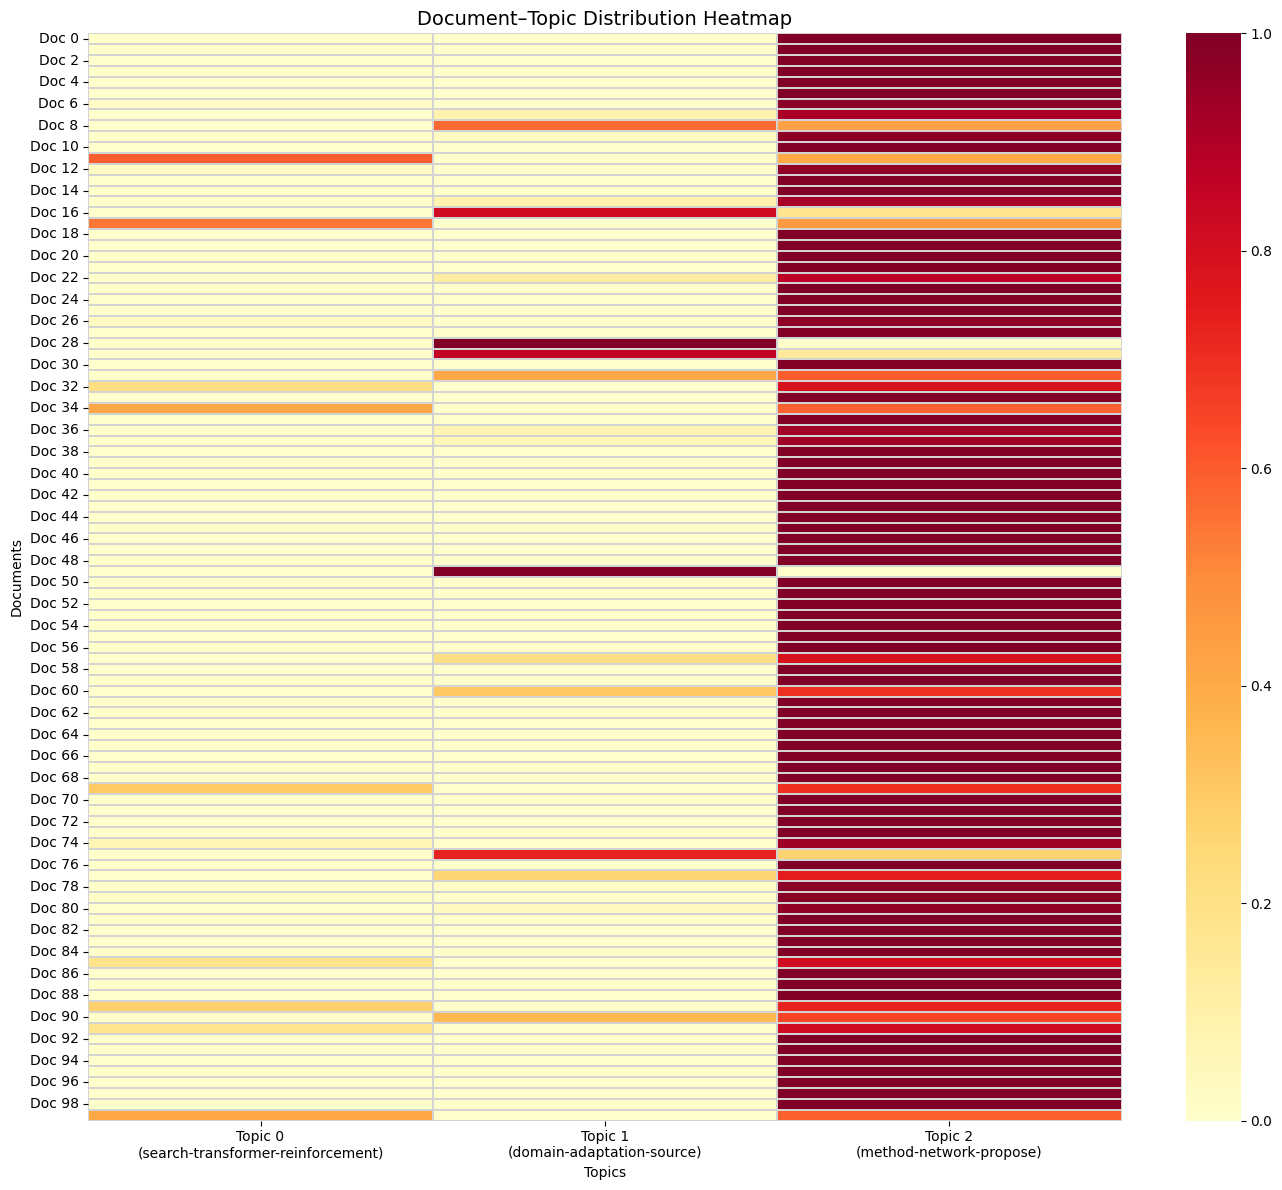

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Grab a sample (e.g. first 50 docs) so the chart is readable
n_docs = 100
topic_dist_sample = topic_distributions[:n_docs]

# Build a labeled DataFrame
n_topics = topic_dist_sample.shape[1]
topic_labels = [f"Topic {i}\n({topic_keywords[i]})" for i in range(n_topics)]

heatmap_df = pd.DataFrame(
    topic_dist_sample,
    columns=topic_labels,
    index=[f"Doc {i}" for i in range(n_docs)]
)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    annot=False,       # set True if you want probability values printed
    linewidths=0.3,
    linecolor='lightgray',
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title("Document–Topic Distribution Heatmap", fontsize=14)
ax.set_xlabel("Topics")
ax.set_ylabel("Documents")
plt.tight_layout()
plt.show()

Referrence:
1. https://medium.com/data-science/understanding-topic-coherence-measures-4aa41339634c
2. https://medium.com/data-science/practical-guide-to-topic-modeling-with-lda-05cd6b027bdf

3.   https://yanlinc.medium.com/how-to-build-a-lda-topic-model-using-from-text-601cdcbfd3a6

